# Loan Limit Term Extension — Optimisation System

## Overview
This notebook implements a **term extension optimisation system** for 30,000 consumer lending customers.

A "loan limit increase" here means **extending the borrowing term by a variable number of days** — not increasing the credit dollar amount. The model determines which customers should receive an extension to maximise portfolio profitability while keeping default risk within regulatory constraints.

### Pipeline
| Step | Component | Method |
|------|-----------|--------|
| 1 | Data Loading & Preprocessing | pandas, StandardScaler |
| 2 | Credit State Classification | Ordinal ranking (Borda count) + K-Means |
| 3 | Macro Data Enrichment | FRED API (cached), World Bank |
| 4 | Markov Chain Analyser | 4-state transition matrix |
| 5 | Demand Forecaster | Stochastic uptake model |
| 6 | Term Extension Simulator | Monte Carlo — 3 outcomes × variable term |
| 7 | LP Optimisation | Binary grant/deny — scipy HiGHS |
| 8 | Solution Validation | 40 correctness properties |
| 9 | Sensitivity Analysis | Optimistic / Baseline / Adverse |
| 10 | Results & Visualisation | 12 charts, CSV export |

### Key model novelties vs a simple credit-limit model
- **Variable term T_i**: drawn from a state-specific lognormal distribution
- **Hazard-rate default**: P(default | T) = 1 − exp(−λ·T/365) — proper continuous-time model
- **Three outcomes**: early repayment / on-time / default — each with distinct cash-flow impact
- **Binary LP**: x_i ∈ {0,1} (relaxed to [0,1] for the LP) — grant or deny, no fractional extension

## 0. Imports & Configuration

In [1]:
# ── Standard library ─────────────────────────────────────────────────────────
import os, json, math, time, warnings
from pathlib import Path
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Any, Optional

warnings.filterwarnings('ignore')

# ── Core ─────────────────────────────────────────────────────────────────────
import numpy  as np
import pandas as pd
from scipy.optimize    import linprog
from scipy.stats       import lognorm
from sklearn.cluster   import KMeans
from sklearn.preprocessing import StandardScaler

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 100, 'figure.figsize': (10, 5)})

print("All imports OK")

All imports OK


In [2]:
# ── Configuration (override via environment variables) ─────────────────────────
DATA_FILE               = Path(os.getenv('DATA_FILE',          'loan_limit_increases.csv'))
RESULTS_FILE            = os.getenv('RESULTS_FILE',            'term_extension_results.csv')
CACHE_DIR               = Path('cache'); CACHE_DIR.mkdir(exist_ok=True)

NPV_DISCOUNT_RATE       = float(os.getenv('NPV_DISCOUNT_RATE',       '0.19'))
SIMULATION_ITERATIONS   = int(  os.getenv('SIMULATION_ITERATIONS',   '3500'))
MAX_PORTFOLIO_DEFAULT_RISK = float(os.getenv('MAX_PORTFOLIO_DEFAULT_RISK', '0.05'))
MAX_TOTAL_EXPOSURE      = float(os.getenv('MAX_TOTAL_EXPOSURE',      '500_000_000'))
MIN_DAYS_SINCE_LOAN     = int(  os.getenv('MIN_DAYS_SINCE_LOAN',     '60'))
LGD                     = float(os.getenv('LGD',                     '0.50'))
PROFIT_PER_EXTENSION    = float(os.getenv('PROFIT_PER_EXTENSION',    '40.0'))
BATCH_SIZE              = int(  os.getenv('BATCH_SIZE',               '5000'))
HORIZON_DAYS            = int(  os.getenv('HORIZON_DAYS',             '365'))

CREDIT_STATES = ['Excellent', 'Good', 'Fair', 'Poor']

# ── Term extension parameters by credit state ──────────────────────────────────
# mean_days  : expected extension length (customer-specific factors shift this)
# std_days   : variability in extension length
# lambda_ann : annual default hazard rate (aligned with FDIC charge-off norms by tier)
# p_early    : probability of early repayment before term expires
TERM_PARAMS = {
    'Excellent': {'mean_days': 90, 'std_days': 12, 'lambda_ann': 0.015, 'p_early': 0.25},
    'Good':      {'mean_days': 75, 'std_days': 15, 'lambda_ann': 0.040, 'p_early': 0.20},
    'Fair':      {'mean_days': 60, 'std_days': 18, 'lambda_ann': 0.100, 'p_early': 0.12},
    'Poor':      {'mean_days': 45, 'std_days': 20, 'lambda_ann': 0.220, 'p_early': 0.05},
}

# ── Macro scenarios ────────────────────────────────────────────────────────────
MACRO_SCENARIOS = {
    'optimistic': {'gdp_growth': 3.5, 'unemployment': 3.5, 'fed_rate': 4.0, 'cpi': 2.5},
    'baseline':   {'gdp_growth': 2.5, 'unemployment': 4.0, 'fed_rate': 5.0, 'cpi': 3.5},
    'adverse':    {'gdp_growth': 0.5, 'unemployment': 5.5, 'fed_rate': 6.0, 'cpi': 5.0},
}

print(f"  Discount rate        : {NPV_DISCOUNT_RATE:.0%}")
print(f"  Simulation iterations: {SIMULATION_ITERATIONS:,}")
print(f"  Max portfolio risk   : {MAX_PORTFOLIO_DEFAULT_RISK:.0%}")
print(f"  Max total exposure   : ${MAX_TOTAL_EXPOSURE:,.0f}")
print(f"  Profit per extension : ${PROFIT_PER_EXTENSION:.0f}")
print(f"  LGD                  : {LGD:.0%}")

  Discount rate        : 19%
  Simulation iterations: 3,500
  Max portfolio risk   : 5%
  Max total exposure   : $500,000,000
  Profit per extension : $40
  LGD                  : 50%


## 1. Data Loading & Preprocessing

In [3]:
def load_and_preprocess_data(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    df = df.rename(columns={
        'Customer ID':             'customer_id',
        'Initial Loan ($)':        'initial_loan',
        'Days Since Last Loan':    'days_since_last_loan',
        'On-time Payments (%)':    'on_time_payments_pct',
        'No. of Increases in 2023':'num_increases_2023',
        'Total Profit Contribution ($)': 'total_profit_contribution',
    })
    assert len(df) == 30_000, f"Expected 30,000 rows, got {len(df)}"
    assert df.isnull().sum().sum() == 0, "Missing values found"

    # Eligibility: >= 60 days since last disbursement + on-time payments
    df['eligible'] = (df['days_since_last_loan'] >= MIN_DAYS_SINCE_LOAN).astype(int)
    df['utilization_rate'] = np.clip(
        1.0 - df['days_since_last_loan'].clip(0, 365) / 365.0, 0.05, 0.95
    )

    # Normalise for credit scoring
    scaler = StandardScaler()
    num_cols = ['initial_loan','days_since_last_loan','on_time_payments_pct',
                'num_increases_2023','total_profit_contribution']
    df_scaled = df.copy()
    df_scaled[num_cols] = scaler.fit_transform(df[num_cols])

    print(f"Loaded {len(df):,} customers")
    print(f"  Eligible (days >= {MIN_DAYS_SINCE_LOAN}): {df['eligible'].sum():,} ({df['eligible'].mean():.1%})")
    print(f"  Loan range: ${df['initial_loan'].min():,.0f} – ${df['initial_loan'].max():,.0f}")
    print(df[['initial_loan','days_since_last_loan','on_time_payments_pct',
              'num_increases_2023']].describe().round(2))
    return df

df_raw = load_and_preprocess_data(DATA_FILE)
df = df_raw.copy()

Loaded 30,000 customers
  Eligible (days >= 60): 25,068 (83.6%)
  Loan range: $500 – $4,999
       initial_loan  days_since_last_loan  on_time_payments_pct  \
count      30000.00              30000.00              30000.00   
mean        2752.53                181.48                 90.02   
std         1293.03                105.07                  5.75   
min          500.00                  0.00                 80.00   
25%         1630.00                 90.00                 85.08   
50%         2761.00                182.00                 90.05   
75%         3866.00                272.00                 95.01   
max         4999.00                364.00                100.00   

       num_increases_2023  
count            30000.00  
mean                 2.24  
std                  2.08  
min                  0.00  
25%                  0.00  
50%                  3.00  
75%                  4.00  
max                  5.00  


## 2. Credit State Classification

In [4]:
def classify_credit_states(df: pd.DataFrame) -> pd.DataFrame:
    """
    Ordinal rank aggregation (Borda count) → composite score → K-Means (k=4).

    Weights (FICO-aligned):
      35% payment history  — on_time_payments_pct
      30% credit discipline — num_increases_2023 (more increases = more credit-seeking)
      20% recency           — days_since_last_loan (more days = less active)
      15% profit value      — total_profit_contribution
    """
    df = df.copy()
    n = len(df)

    r_pay  = df['on_time_payments_pct'].rank(pct=True)
    r_disc = (1 - df['num_increases_2023'].rank(pct=True))   # fewer increases = better
    r_rec  = (1 - df['days_since_last_loan'].rank(pct=True)) # more recent = better
    r_val  = df['total_profit_contribution'].rank(pct=True)

    df['credit_score'] = (r_pay * 0.35 + r_disc * 0.30 + r_rec * 0.20 + r_val * 0.15)

    # K-Means (k=4) on credit score
    km = KMeans(n_clusters=4, random_state=42, n_init=20)
    km.fit(df[['credit_score']])
    centroids = km.cluster_centers_.flatten()
    order = np.argsort(centroids)[::-1]  # highest centroid = Excellent
    label_map = {old: CREDIT_STATES[new] for new, old in enumerate(order)}
    df['credit_state'] = [label_map[c] for c in km.labels_]

    # Default risk: rank within state anchored to state base rate
    base = {'Excellent': 0.010, 'Good': 0.030, 'Fair': 0.080, 'Poor': 0.200}
    dr = np.zeros(n)
    for state in CREDIT_STATES:
        mask = df['credit_state'] == state
        within = df.loc[mask, 'credit_score'].rank(pct=True)
        dr[mask.values] = np.clip(base[state] * (0.5 + within), 0.001, 0.99)
    df['default_risk'] = dr
    df['high_risk_flag'] = (df['default_risk'] > 0.15).astype(int)

    print("Credit state distribution:")
    print(df['credit_state'].value_counts().reindex(CREDIT_STATES))
    print(f"\nDefault risk: mean={df['default_risk'].mean():.3f}  "
          f"min={df['default_risk'].min():.3f}  max={df['default_risk'].max():.3f}")
    return df

df = classify_credit_states(df)

Credit state distribution:
credit_state
Excellent    6329
Good         9209
Fair         9000
Poor         5462
Name: count, dtype: int64

Default risk: mean=0.072  min=0.005  max=0.300


## 3. Macro Data Enrichment

In [5]:
def fetch_macro_data(year: int = 2023) -> Dict[str, float]:
    cache_file = CACHE_DIR / f'macro_{year}.json'
    if cache_file.exists():
        with open(cache_file) as f:
            data = json.load(f)
        print(f"  Macro data loaded from cache: {cache_file}")
        return data
    # Fallback baseline values (2023 actuals)
    data = {'gdp_growth': 2.5, 'unemployment': 4.0, 'fed_rate': 5.0,
            'cpi': 3.5, 'inflation': 3.5}
    with open(cache_file, 'w') as f:
        json.dump(data, f)
    print("  Using baseline macro values (FRED cache not found)")
    return data

def enrich_with_macro(df: pd.DataFrame, macro: Dict[str, float]) -> pd.DataFrame:
    """
    Adjust hazard rates for macro conditions.
    Higher unemployment / fed rate → higher default hazard.
    Lower GDP growth → shorter terms offered.
    """
    df = df.copy()
    unemp_adj = (macro.get('unemployment', 4.0) - 4.0) * 0.01  # +1pp unemp → +1pp hazard
    rate_adj  = (macro.get('fed_rate',     5.0) - 5.0) * 0.005 # +1pp rate → +0.5pp hazard
    macro_risk_adj = 1.0 + unemp_adj + rate_adj

    df['default_risk'] = np.clip(df['default_risk'] * macro_risk_adj, 0.001, 0.99)

    gdp_adj = (macro.get('gdp_growth', 2.5) - 2.5) / 100.0
    df['term_adj_days'] = gdp_adj * 10   # +1pp GDP → +10 days offered

    df['macro_gdp_growth']   = macro.get('gdp_growth',   2.5)
    df['macro_unemployment'] = macro.get('unemployment', 4.0)
    df['macro_fed_rate']     = macro.get('fed_rate',     5.0)
    df['macro_cpi']          = macro.get('cpi',          3.5)
    print(f"  Macro risk adjustment: ×{macro_risk_adj:.3f}")
    return df

macro_data = fetch_macro_data()
df = enrich_with_macro(df, macro_data)
print("Macro enrichment complete")
print(f"  Adjusted default risk: mean={df['default_risk'].mean():.4f}")

  Using baseline macro values (FRED cache not found)
  Macro risk adjustment: ×1.000
Macro enrichment complete
  Adjusted default risk: mean=0.0717


## 4. Markov Chain — Credit State Transitions

In [6]:
@dataclass
class TransitionMatrix:
    matrix:       np.ndarray
    state_labels: List[str]
    steady_state: np.ndarray
    observation_period_days: int = 90

def compute_steady_state(T: np.ndarray) -> np.ndarray:
    evals, evecs = np.linalg.eig(T.T)
    idx = np.argmin(np.abs(evals - 1.0))
    ss = np.abs(evecs[:, idx].real)
    return ss / ss.sum()

def build_transition_matrix(df: pd.DataFrame) -> TransitionMatrix:
    """
    Estimate 4×4 transition matrix from payment behaviour.

    Logic: customers with high on-time payment rate trend toward better states;
    high num_increases (credit-seeking) and low profit trend toward worse states.
    """
    n = len(CREDIT_STATES)
    # Base transition (near-identity with small off-diagonal flow)
    T = np.array([
        [0.88, 0.09, 0.02, 0.01],   # Excellent → ...
        [0.08, 0.82, 0.08, 0.02],   # Good      → ...
        [0.02, 0.10, 0.78, 0.10],   # Fair      → ...
        [0.01, 0.05, 0.18, 0.76],   # Poor      → ...
    ], dtype=np.float64)

    # Adjust off-diagonals using portfolio payment behaviour
    avg_ontime = df['on_time_payments_pct'].mean() / 100.0
    improvement_factor = (avg_ontime - 0.85) * 2.0   # > 0 if above 85%

    for i in range(n - 1):
        shift = np.clip(improvement_factor * 0.02, -0.05, 0.05)
        T[i, i]     = np.clip(T[i, i]     + shift, 0.01, 0.99)
        T[i, i + 1] = np.clip(T[i, i + 1] - shift, 0.01, 0.99)

    # Row-normalise
    T = T / T.sum(axis=1, keepdims=True)
    ss = compute_steady_state(T)

    tm = TransitionMatrix(matrix=T, state_labels=CREDIT_STATES,
                          steady_state=ss, observation_period_days=90)
    print("Transition matrix:")
    print(pd.DataFrame(T, index=CREDIT_STATES, columns=CREDIT_STATES).round(4).to_string())
    print(f"\nSteady-state probabilities:")
    for s, p in zip(CREDIT_STATES, ss):
        print(f"  {s:<12}: {p:.3f} ({p*100:.1f}%)")
    return tm

transition_matrix = build_transition_matrix(df)

Transition matrix:
           Excellent   Good   Fair   Poor
Excellent      0.882  0.088  0.020  0.010
Good           0.080  0.822  0.078  0.020
Fair           0.020  0.100  0.782  0.098
Poor           0.010  0.050  0.180  0.760

Steady-state probabilities:
  Excellent   : 0.274 (27.4%)
  Good        : 0.322 (32.2%)
  Fair        : 0.259 (25.9%)
  Poor        : 0.144 (14.4%)


## 5. Demand Forecasting — Uptake Probability

In [7]:
def forecast_uptake(df: pd.DataFrame, macro: Dict[str, float],
                    n_scenarios: int = 3500) -> pd.DataFrame:
    """
    Stochastic uptake model: probability a customer accepts a term extension offer.

    Factors:
      - Credit state: better customers have higher uptake (they benefit more)
      - Profit history: higher existing profit → more engaged → higher uptake
      - Macro: adverse conditions reduce uptake (customers more cautious)
    """
    df = df.copy()
    rng = np.random.default_rng(42)

    # Base uptake by state
    base_uptake = {'Excellent': 0.80, 'Good': 0.70, 'Fair': 0.55, 'Poor': 0.35}

    # Macro adjustment
    gdp_adj  = (macro.get('gdp_growth',   2.5) - 2.5) * 0.02
    unemp_adj = -(macro.get('unemployment', 4.0) - 4.0) * 0.03
    macro_adj = gdp_adj + unemp_adj

    uptake_rates = np.zeros(len(df))
    uptake_std   = np.zeros(len(df))

    for state in CREDIT_STATES:
        mask = df['credit_state'] == state
        nc   = mask.sum()
        base = base_uptake[state] + macro_adj

        # Customer-level variation: higher profit history → higher uptake
        profit_score = df.loc[mask, 'total_profit_contribution']
        profit_rank  = profit_score.rank(pct=True) * 0.10   # ±5pp around base

        # Monte Carlo uptake draws
        mu_u   = np.clip(base + profit_rank.values - 0.05, 0.05, 0.95)
        draws  = rng.beta(mu_u * 10, (1 - mu_u) * 10, (n_scenarios, nc))
        uptake_rates[mask.values] = draws.mean(axis=0)
        uptake_std  [mask.values] = draws.std(axis=0)

    df['uptake_probability'] = np.clip(uptake_rates, 0.01, 0.99)
    df['uptake_std']         = uptake_std

    print(f"Uptake forecast (macro adj={macro_adj:+.3f}):")
    for state in CREDIT_STATES:
        mask = df['credit_state'] == state
        u = df.loc[mask, 'uptake_probability']
        print(f"  {state:<10}: mean={u.mean():.2f}  std={u.std():.3f}")
    return df

df = forecast_uptake(df, macro_data)

Uptake forecast (macro adj=+0.000):
  Excellent : mean=0.80  std=0.025
  Good      : mean=0.70  std=0.027
  Fair      : mean=0.55  std=0.028
  Poor      : mean=0.35  std=0.028


## 6. Term Extension Monte Carlo Simulation

In [8]:
# ── Mathematical foundation ─────────────────────────────────────────────────────
#
# Each extension offer can result in THREE outcomes:
#
#   1. Early repayment  (prob p_early_i):
#      Customer repays before term ends. No default. Revenue = $40.
#
#   2. On-time repayment (prob p_ontime_i):
#      Customer completes the full term, repays normally. Revenue = $40.
#
#   3. Default (prob p_default_i):
#      Customer fails to repay during the extended term.
#      Revenue = $40 (already earned at extension grant time).
#      Loss = loan_amount × LGD.
#
# Default probability uses a hazard-rate (exponential) model:
#   P(default in T days) = 1 - exp(-lambda_i * T / 365)
#
# where lambda_i is the annual default hazard rate for customer i,
# informed by their credit state and macro conditions.
#
# Variable term T_i drawn from a lognormal distribution:
#   T_i ~ LogNormal(mu_ln, sigma_ln)  [days]
# with mu_ln and sigma_ln derived from state-specific mean/std parameters.
#
# NPV calculation:
#   Revenue: earned at t=0 (extension grant) — NPV = $40 * npv_factor
#   Loss:    occurs at expected midpoint t=T/2 — discounted at 19% annual rate
#   npv_factor = (1 - exp(-r * T/365)) / (r * T/365)  [mid-period annuity factor]

def simulate_term_extensions(
    df: pd.DataFrame,
    n_iterations: int = SIMULATION_ITERATIONS,
    discount_rate: float = NPV_DISCOUNT_RATE,
    batch_size:    int   = BATCH_SIZE,
) -> pd.DataFrame:
    """
    Vectorised Monte Carlo simulation of term extension outcomes.

    For each customer simulates n_iterations scenarios of:
      - Extension term T (days) drawn from lognormal by credit state
      - Repayment outcome: early / on-time / default
      - NPV-discounted revenue and loss for each scenario

    Returns DataFrame enriched with:
      expected_revenue, expected_loss, profitability_score,
      expected_term_days, p_default_sim, p_early_sim
    """
    t0  = time.time()
    n   = len(df)
    rng = np.random.default_rng(42)

    print(f"Simulating {n:,} customers | {n_iterations:,} iterations each")

    # Output arrays
    revenues      = np.zeros(n, np.float64)
    losses        = np.zeros(n, np.float64)
    exp_terms     = np.zeros(n, np.float64)
    p_def_sim     = np.zeros(n, np.float64)
    p_early_sim   = np.zeros(n, np.float64)

    n_batches = math.ceil(n / batch_size)
    for b in range(n_batches):
        s, e = b * batch_size, min((b + 1) * batch_size, n)
        nc   = e - s

        L      = df['initial_loan'].values[s:e].astype(np.float32)
        states = df['credit_state'].values[s:e]

        rev_batch   = np.zeros((nc, n_iterations), np.float32)
        loss_batch  = np.zeros((nc, n_iterations), np.float32)
        term_batch  = np.zeros((nc, n_iterations), np.float32)
        def_batch   = np.zeros((nc, n_iterations), np.float32)
        early_batch = np.zeros((nc, n_iterations), np.float32)

        for idx, (i, state) in enumerate(zip(range(s, e), states)):
            p = TERM_PARAMS[state]

            # Lognormal parameters from mean/std
            mu_d, std_d = p['mean_days'], p['std_days']
            sigma_ln = math.sqrt(math.log(1 + (std_d / mu_d) ** 2))
            mu_ln    = math.log(mu_d) - sigma_ln ** 2 / 2.0

            # Macro term adjustment (from enrichment step)
            term_adj = float(df['term_adj_days'].values[i]) if 'term_adj_days' in df.columns else 0.0

            # Draw extension terms (days): clip to [30, 180]
            T = np.clip(
                np.exp(mu_ln + sigma_ln * rng.standard_normal(n_iterations)) + term_adj,
                30.0, 180.0
            ).astype(np.float32)

            # Hazard rate default probability per scenario
            lam = p['lambda_ann']
            p_def_T = (1.0 - np.exp(-lam * T / 365.0)).astype(np.float32)

            # Three-outcome draw
            p_early = p['p_early']
            u1 = rng.random(n_iterations, dtype=np.float32)
            u2 = rng.random(n_iterations, dtype=np.float32)

            is_early   = u1 < p_early
            is_default = (~is_early) & (u2 < p_def_T)

            # NPV factor: $40 earned at t=0; discount is applied as mid-period annuity
            npv_factor = ((1.0 - np.exp(-discount_rate * T / 365.0))
                          / (discount_rate * T / 365.0 + 1e-10)).astype(np.float32)

            # Loss discounted to mid-term
            npv_loss = np.exp(-discount_rate * T / 730.0).astype(np.float32)

            rev_batch  [idx] = PROFIT_PER_EXTENSION * npv_factor
            loss_batch [idx] = L[idx] * LGD * is_default.astype(np.float32) * npv_loss
            term_batch [idx] = T
            def_batch  [idx] = is_default.astype(np.float32)
            early_batch[idx] = is_early.astype(np.float32)

        revenues   [s:e] = rev_batch.mean(axis=1)
        losses     [s:e] = loss_batch.mean(axis=1)
        exp_terms  [s:e] = term_batch.mean(axis=1)
        p_def_sim  [s:e] = def_batch.mean(axis=1)
        p_early_sim[s:e] = early_batch.mean(axis=1)

        if n_batches > 1:
            print(f"  Batch {b+1}/{n_batches} done")

    df = df.copy()
    df['expected_revenue']     = revenues
    df['expected_loss']        = losses
    df['profitability_score']  = revenues - losses
    df['expected_term_days']   = exp_terms
    df['p_default_sim']        = p_def_sim
    df['p_early_sim']          = p_early_sim

    print(f"\nSimulation completed in {time.time()-t0:.1f}s")
    print(f"  Expected term (mean): {exp_terms.mean():.1f} days")
    print(f"  P(default) (mean)   : {p_def_sim.mean():.4f}")
    print(f"  P(early)   (mean)   : {p_early_sim.mean():.4f}")
    print(f"  Expected revenue    : ${revenues.mean():.2f}")
    print(f"  Expected loss       : ${losses.mean():.2f}")
    print(f"  Profitability score : ${(revenues - losses).mean():.2f}")
    return df

df = simulate_term_extensions(df)

Simulating 30,000 customers | 3,500 iterations each


  Batch 1/6 done


  Batch 2/6 done


  Batch 3/6 done


  Batch 4/6 done


  Batch 5/6 done


  Batch 6/6 done

Simulation completed in 5.7s
  Expected term (mean): 68.5 days
  P(default) (mean)   : 0.0116
  P(early)   (mean)   : 0.1592
  Expected revenue    : $39.30
  Expected loss       : $15.77
  Profitability score : $23.53


## 7. Constraint Definition

In [9]:
def create_constraints() -> Dict[str, float]:
    return {
        'max_portfolio_default_risk': MAX_PORTFOLIO_DEFAULT_RISK,
        'max_total_exposure':         MAX_TOTAL_EXPOSURE,
    }

constraints = create_constraints()
print("Constraint set:")
for k, v in constraints.items():
    print(f"  {k}: {v:,.4f}")

Constraint set:
  max_portfolio_default_risk: 0.0500
  max_total_exposure: 500,000,000.0000


## 8. LP Optimisation — Binary Term Extension Decisions

In [10]:
# ── Mathematical formulation ────────────────────────────────────────────────────
#
# Decision variables:
#   x_i ∈ [0, 1]  — whether customer i receives a term extension
#   (LP relaxation of binary {0,1}; corner solutions dominate in practice)
#
# Objective (maximise expected NPV profit):
#   Maximise  Σ_i  π_i · x_i
#   where  π_i = expected_revenue_i − expected_loss_i
#              = E[40 · npv(T_i)] − E[L_i · LGD · 1(default_i) · npv_loss(T_i)]
#
# Constraints:
#   (1) Weighted default risk on extended exposure ≤ max_portfolio_default_risk:
#       Σ_i (p_default_i − max_risk) · L_i · x_i  ≤  0
#
#   (2) Total extended exposure ≤ max_total_exposure:
#       Σ_i  L_i · x_i  ≤  max_total_exposure − Σ_i L_i
#
#   (3) Eligibility:  x_i = 0  if  days_since_last_loan < 60  (bound collapse)
#
#   (4) Box bounds:   x_i ∈ [0, 1]

def _greedy_fallback(df, constraints, profit_scores):
    """Greedy grant by profitability when LP solver fails."""
    x = np.zeros(len(df))
    order = np.argsort(-profit_scores)
    budget = constraints['max_total_exposure'] - df['initial_loan'].sum()
    for i in order:
        if profit_scores[i] <= 0:
            break
        if x[i] == 0 and budget >= df['initial_loan'].iloc[i]:
            x[i] = 1.0
            budget -= df['initial_loan'].iloc[i]
    return x

def optimize_extensions_lp(
    df: pd.DataFrame,
    constraints: Dict[str, float],
    solver_timeout: int = 300,
) -> Tuple[pd.DataFrame, int]:
    t0  = time.time()
    n   = len(df)
    print(f"Setting up LP: {n:,} binary extension decisions...")

    # ── Objective ───────────────────────────────────────────────────────────────
    profit_scores = df['profitability_score'].values
    c_obj = -profit_scores   # negate → minimisation

    # ── Bounds: x_i ∈ [0,1]; ineligible customers clamped to [0,0] ─────────────
    ub = np.ones(n, dtype=np.float64)
    if 'eligible' in df.columns:
        ineligible_mask = df['eligible'].values == 0
        ub[ineligible_mask] = 0.0
        n_inelig = ineligible_mask.sum()
        print(f"  Eligibility filter: {n_inelig:,} customers excluded (days_since_last_loan < {MIN_DAYS_SINCE_LOAN})")
    bounds = list(zip(np.zeros(n), ub))

    # ── Inequality constraints (A_ub @ x ≤ b_ub) ───────────────────────────────
    A_ub_rows, b_ub_vals = [], []

    # (1) Weighted default risk on extended exposure:
    #     Σ (p_def_i − max_risk) · L_i · x_i ≤ 0
    max_risk  = constraints['max_portfolio_default_risk']
    risk_coef = (df['p_default_sim'].values - max_risk) * df['initial_loan'].values
    A_ub_rows.append(risk_coef)
    b_ub_vals.append(0.0)

    # (2) Total extended exposure ≤ remaining capital budget
    total_existing = df['initial_loan'].sum()
    budget_remaining = constraints['max_total_exposure'] - total_existing
    A_ub_rows.append(df['initial_loan'].values.copy())
    b_ub_vals.append(max(budget_remaining, 0.0))

    A_ub = np.vstack(A_ub_rows)
    b_ub = np.array(b_ub_vals)

    # ── Solve ───────────────────────────────────────────────────────────────────
    print("Solving LP with HiGHS solver ...")
    result = linprog(
        c_obj, A_ub=A_ub, b_ub=b_ub, bounds=bounds,
        method='highs',
        options={'time_limit': solver_timeout, 'disp': False}
    )
    elapsed = time.time() - t0
    print(f"LP solved in {elapsed:.2f}s  |  Status: {result.message}")

    if result.success:
        x = np.clip(result.x, 0.0, 1.0)
        # Round: x > 0.5 → grant extension (LP relaxation corner solutions)
        granted = (x > 0.5).astype(float)
        status_code = 0
    else:
        print("WARNING: LP did not converge — greedy fallback")
        granted = _greedy_fallback(df, constraints, profit_scores)
        status_code = result.status

    results = pd.DataFrame({
        'customer_id':         df['customer_id'].values,
        'initial_loan':        df['initial_loan'].values,
        'credit_state':        df['credit_state'].values,
        'default_risk':        df['default_risk'].values,
        'p_default_sim':       df['p_default_sim'].values,
        'p_early_sim':         df['p_early_sim'].values,
        'expected_term_days':  df['expected_term_days'].values,
        'uptake_probability':  df.get('uptake_probability', pd.Series(np.ones(len(df)))).values,
        'profitability_score': df['profitability_score'].values,
        'expected_revenue':    df['expected_revenue'].values,
        'expected_loss':       df['expected_loss'].values,
        'extension_granted':   granted,
        'eligible':            df['eligible'].values,
    })

    n_granted = int(granted.sum())
    granted_mask = granted > 0.5
    rev_total  = results.loc[granted_mask, 'expected_revenue'].sum()
    loss_total = results.loc[granted_mask, 'expected_loss'].sum()
    exp_out    = (results.loc[granted_mask, 'initial_loan'] * granted[granted_mask]).sum()

    print(f"\nOptimisation results:")
    print(f"  Extensions granted     : {n_granted:,}  ({100*n_granted/len(df):.1f}% of portfolio)")
    print(f"  Total extended exposure: ${exp_out:>14,.0f}")
    print(f"  Expected revenue       : ${rev_total:>14,.0f}")
    print(f"  Expected credit loss   : ${loss_total:>14,.0f}")
    print(f"  Net expected profit    : ${rev_total - loss_total:>14,.0f}")
    return results, status_code

results_df, lp_status = optimize_extensions_lp(df, constraints)
print(f"\nSolver status: {lp_status} ({'Optimal' if lp_status == 0 else 'Sub-optimal'})")

Setting up LP: 30,000 binary extension decisions...
  Eligibility filter: 4,932 customers excluded (days_since_last_loan < 60)
Solving LP with HiGHS solver ...
LP solved in 0.13s  |  Status: Optimization terminated successfully. (HiGHS Status 7: Optimal)

Optimisation results:
  Extensions granted     : 22,676  (75.6% of portfolio)
  Total extended exposure: $    59,220,281
  Expected revenue       : $       891,024
  Expected credit loss   : $       301,865
  Net expected profit    : $       589,159

Solver status: 0 (Optimal)


## 9. LP–Markov Feedback Loop

In [11]:
def apply_policy_to_transitions(df, granted, tm, policy_strength=0.12):
    """
    Extend granted customers have improved transition probabilities:
    receiving an extension (and making payments) shifts probability mass
    toward better credit states.
    """
    adj = tm.matrix.copy()
    n_states = len(CREDIT_STATES)

    frac_granted = granted.mean()
    # Granting extensions → customers more engaged → drift toward better states
    shift = policy_strength * frac_granted
    for i in range(n_states - 1):
        adj[i + 1, i]     = np.clip(adj[i + 1, i]     + shift, 0.01, 0.50)
        adj[i + 1, i + 1] = np.clip(adj[i + 1, i + 1] - shift, 0.01, 0.99)

    adj = adj / adj.sum(axis=1, keepdims=True)
    return adj

def lp_markov_feedback(df, constraints, tm, max_iter=5, tol=0.5, policy_strength=0.12):
    current_df  = df.copy()
    prev_granted = None
    log = []
    poor_idx = CREDIT_STATES.index('Poor')
    base_poor = tm.steady_state[poor_idx]

    for it in range(1, max_iter + 1):
        print(f"\n  [Iteration {it}/{max_iter}]")
        res_df, _ = optimize_extensions_lp(current_df, constraints)
        granted   = res_df['extension_granted'].values

        if prev_granted is not None:
            delta = np.abs(granted - prev_granted).mean()
            print(f"    Mean |Δ granted| : {delta:.4f}")
            if delta < tol:
                print(f"    Converged.")
                break

        adj_matrix = apply_policy_to_transitions(current_df, granted, tm, policy_strength)
        adj_ss     = compute_steady_state(adj_matrix)
        adj_poor   = adj_ss[poor_idx]

        risk_scale = np.clip((base_poor + adj_poor) / (2.0 * base_poor), 0.80, 1.20)
        current_df['default_risk']  = np.clip(df['default_risk'].values * risk_scale, 0.001, 0.99)
        current_df['p_default_sim'] = np.clip(df['p_default_sim'].values * risk_scale, 0.001, 0.60)
        # Re-derive profitability with adjusted loss
        current_df['expected_loss']       = df['expected_loss'].values * risk_scale
        current_df['profitability_score'] = current_df['expected_revenue'] - current_df['expected_loss']

        n_granted = int(granted.sum())
        obj_val   = float((res_df['profitability_score'] * granted).sum())
        log.append({'iteration': it, 'n_granted': n_granted,
                    'poor_steady': float(adj_poor), 'risk_scale': float(risk_scale),
                    'objective': obj_val})
        print(f"    Extensions granted : {n_granted:,}")
        print(f"    Poor steady-state  : {adj_poor:.4f}  (base: {base_poor:.4f})")
        print(f"    Risk scale         : {risk_scale:.4f}")
        print(f"    Objective          : ${obj_val:,.0f}")

        prev_granted = granted.copy()
        tm = TransitionMatrix(matrix=adj_matrix, state_labels=CREDIT_STATES,
                              steady_state=adj_ss,
                              observation_period_days=tm.observation_period_days)

    return res_df, current_df, tm, log

print("=== LP–Markov Feedback Loop ===")
results_df, df, transition_matrix_adjusted, feedback_log = lp_markov_feedback(
    df, constraints, transition_matrix, max_iter=5, tol=0.5, policy_strength=0.12
)
lp_status = 0

print("\n=== Feedback Loop Summary ===")
print(f"{'Iter':<6} {'Granted':>10} {'Poor SS':>10} {'Risk Scale':>12} {'Objective':>14}")
print("-" * 54)
for row in feedback_log:
    print(f"{row['iteration']:<6} {row['n_granted']:>10,} "
          f"{row['poor_steady']*100:>9.2f}% "
          f"{row['risk_scale']:>12.4f} "
          f"${row['objective']:>13,.0f}")

=== LP–Markov Feedback Loop ===

  [Iteration 1/5]
Setting up LP: 30,000 binary extension decisions...
  Eligibility filter: 4,932 customers excluded (days_since_last_loan < 60)
Solving LP with HiGHS solver ...


LP solved in 0.10s  |  Status: Optimization terminated successfully. (HiGHS Status 7: Optimal)

Optimisation results:
  Extensions granted     : 22,676  (75.6% of portfolio)
  Total extended exposure: $    59,220,281
  Expected revenue       : $       891,024
  Expected credit loss   : $       301,865
  Net expected profit    : $       589,159
    Extensions granted : 22,676
    Poor steady-state  : 0.0830  (base: 0.1442)
    Risk scale         : 0.8000
    Objective          : $589,159

  [Iteration 2/5]
Setting up LP: 30,000 binary extension decisions...
  Eligibility filter: 4,932 customers excluded (days_since_last_loan < 60)
Solving LP with HiGHS solver ...
LP solved in 0.10s  |  Status: Optimization terminated successfully. (HiGHS Status 7: Optimal)

Optimisation results:
  Extensions granted     : 23,713  (79.0% of portfolio)
  Total extended exposure: $    63,010,108
  Expected revenue       : $       931,991
  Expected credit loss   : $       278,091
  Net expected profit    :

    Mean |Δ granted| : 0.0346
    Converged.

=== Feedback Loop Summary ===
Iter      Granted    Poor SS   Risk Scale      Objective
------------------------------------------------------
1          22,676      8.30%       0.8000 $      589,159


## 10. Solution Validation

In [12]:
def validate_solution(results, df, constraints):
    tol = 1e-3
    granted = results['extension_granted'].values
    granted_mask = granted > 0.5
    report = {}

    checks = {}
    def check(name, val, msg=''):
        checks[name] = val
        print(f"  {'✓' if val else '✗'} {name:<50} {msg}")

    print("=== Validation Checks ===\n")

    # P1: 30,000 customers
    check('P1_CustomerCount', len(results) == 30_000, f"n={len(results):,}")

    # P2: No ineligible customers granted
    inelig_granted = (results.loc[~results['eligible'].astype(bool), 'extension_granted'] > 0.5).sum()
    check('P2_EligibilityEnforced', inelig_granted == 0, f"ineligible_granted={inelig_granted}")

    # P3: All profitability scores finite
    check('P3_FiniteProfitability', np.isfinite(results['profitability_score']).all())

    # P4: Non-negative expected revenue
    check('P4_NonNegativeRevenue', (results['expected_revenue'] >= 0).all())

    # P5: Non-negative expected loss
    check('P5_NonNegativeLoss', (results['expected_loss'] >= 0).all())

    # P6: extension_granted in {0, 1}
    vals = results['extension_granted'].unique()
    check('P6_BinaryDecision', set(np.round(vals, 5)).issubset({0.0, 1.0}),
          f"unique values: {vals[:5]}")

    # P7: Simulation iterations >= 3000
    check('P7_SimulationIterations', SIMULATION_ITERATIONS >= 3000,
          f"n_iterations={SIMULATION_ITERATIONS:,}")

    # P8: Default probabilities in [0, 1]
    check('P8_DefaultProbRange',
          ((results['p_default_sim'] >= 0) & (results['p_default_sim'] <= 1)).all())

    # P9: Expected term days > 0
    check('P9_PositiveTerm', (results['expected_term_days'] > 0).all())

    # P10: Risk constraint satisfied
    if granted_mask.sum() > 0:
        granted_res = results[granted_mask]
        total_L = (granted_res['initial_loan'] * granted_res['extension_granted']).sum()
        risk_L  = (granted_res['p_default_sim'] * granted_res['initial_loan']
                   * granted_res['extension_granted']).sum()
        port_risk = risk_L / max(total_L, 1.0)
        check('P10_RiskConstraint',
              port_risk <= constraints['max_portfolio_default_risk'] + tol,
              f"portfolio_risk={port_risk:.4f} vs cap={constraints['max_portfolio_default_risk']:.4f}")
        report['portfolio_default_risk'] = float(port_risk)

    # P11: Exposure constraint
    exp_total = (results.loc[granted_mask, 'initial_loan']).sum()
    check('P11_ExposureConstraint',
          exp_total <= constraints['max_total_exposure'] + tol,
          f"${exp_total:,.0f} vs ${constraints['max_total_exposure']:,.0f}")

    # P12: Net profit positive
    net_profit = (results.loc[granted_mask, 'profitability_score']).sum()
    check('P12_PositiveNetProfit', net_profit > 0, f"${net_profit:,.0f}")
    report['net_profit'] = float(net_profit)

    # P13: Steady-state sums to 1
    check('P13_SteadyStateNorm',
          abs(transition_matrix.steady_state.sum() - 1.0) < 1e-6,
          f"sum={transition_matrix.steady_state.sum():.8f}")

    # P14: Transition matrix rows sum to 1
    row_sums = transition_matrix.matrix.sum(axis=1)
    check('P14_TransitionRowNorm', np.allclose(row_sums, 1.0, atol=1e-6),
          f"row_sums: {row_sums.round(4)}")

    # P15: At least 10,000 customers with extensions
    n_granted = int(granted_mask.sum())
    check('P15_MinGranted', n_granted >= 5000, f"n_granted={n_granted:,}")

    # P16: Uptake probabilities in [0,1]
    check('P16_UptakeProbRange',
          ((df['uptake_probability'] >= 0) & (df['uptake_probability'] <= 1)).all())

    # P17: Discount rate is 19%
    check('P17_DiscountRate', abs(NPV_DISCOUNT_RATE - 0.19) < 1e-6,
          f"rate={NPV_DISCOUNT_RATE}")

    # P18: Profit per extension is $40
    check('P18_ProfitPerExtension', PROFIT_PER_EXTENSION == 40.0,
          f"profit=${PROFIT_PER_EXTENSION}")

    # P19: High-risk flag threshold at 15%
    check('P19_HighRiskFlag', (df['high_risk_flag'] == (df['default_risk'] > 0.15)).all())

    # P20: Four credit states present
    check('P20_FourStates',
          set(results['credit_state'].unique()) == set(CREDIT_STATES),
          str(sorted(results['credit_state'].unique())))

    passed = sum(checks.values())
    total  = len(checks)
    report.update({'passed': passed == total, 'checks': checks,
                   'n_checks': total, 'n_passed': passed})
    print(f"\nOverall: {'✓ PASSED' if passed == total else '✗ FAILED'} — {passed}/{total}")
    return report

validation = validate_solution(results_df, df, constraints)

=== Validation Checks ===

  ✓ P1_CustomerCount                                   n=30,000
  ✓ P2_EligibilityEnforced                             ineligible_granted=0
  ✓ P3_FiniteProfitability                             
  ✓ P4_NonNegativeRevenue                              
  ✓ P5_NonNegativeLoss                                 
  ✓ P6_BinaryDecision                                  unique values: [1. 0.]
  ✓ P7_SimulationIterations                            n_iterations=3,500
  ✓ P8_DefaultProbRange                                
  ✓ P9_PositiveTerm                                    
  ✓ P10_RiskConstraint                                 portfolio_risk=0.0090 vs cap=0.0500
  ✓ P11_ExposureConstraint                             $63,010,108 vs $500,000,000
  ✓ P12_PositiveNetProfit                              $653,900
  ✓ P13_SteadyStateNorm                                sum=1.00000000
  ✓ P14_TransitionRowNorm                              row_sums: [1. 1. 1. 1.]
  ✓ P15_MinGra

## 11. Sensitivity Analysis — Macro Scenarios

In [13]:
def sensitivity_analysis(df, constraints, macro_scenarios):
    risk_mult = {'optimistic': 0.80, 'baseline': 1.00, 'adverse': 1.35}
    loss_adj  = {'optimistic': 0.85, 'baseline': 1.00, 'adverse': 1.25}
    term_adj  = {'optimistic': +5.0, 'baseline': 0.0,  'adverse': -5.0}  # days

    rows = []
    for name, macro_params in macro_scenarios.items():
        print(f"\n--- Scenario: {name.upper()} ---")
        df_s = df.copy()
        df_s = enrich_with_macro(df_s, macro_params)
        df_s['p_default_sim']      = np.clip(df['p_default_sim'] * risk_mult[name], 0.0, 0.60)
        df_s['expected_loss']      = df['expected_loss'] * loss_adj[name]
        df_s['expected_term_days'] = np.clip(df['expected_term_days'] + term_adj[name], 30, 180)
        df_s['profitability_score'] = df_s['expected_revenue'] - df_s['expected_loss']

        s_constraints = dict(constraints)
        if name == 'adverse':
            s_constraints['max_portfolio_default_risk'] *= 0.90
        elif name == 'optimistic':
            s_constraints['max_portfolio_default_risk'] *= 1.10

        res_s, _ = optimize_extensions_lp(df_s, s_constraints, solver_timeout=120)
        granted  = res_s['extension_granted'].values
        gm       = granted > 0.5
        n_g      = int(gm.sum())
        net_p    = float((res_s.loc[gm, 'expected_revenue'] - res_s.loc[gm, 'expected_loss']).sum())
        port_r   = float((res_s.loc[gm,'p_default_sim'] * res_s.loc[gm,'initial_loan']).sum()
                         / max(res_s.loc[gm,'initial_loan'].sum(), 1.0))
        rows.append({'scenario': name, 'n_granted': n_g,
                     'net_profit': net_p, 'portfolio_risk': port_r,
                     'risk_mult': risk_mult[name], 'term_adj': term_adj[name]})
        print(f"  Extensions granted: {n_g:,}  |  Net profit: ${net_p:,.0f}  |  Risk: {port_r:.4f}")

    sensitivity_df = pd.DataFrame(rows)
    print("\n=== Scenario Comparison ===")
    print(sensitivity_df[['scenario','n_granted','net_profit','portfolio_risk']].to_string(index=False))
    return sensitivity_df

sensitivity_results = sensitivity_analysis(df, constraints, MACRO_SCENARIOS)


--- Scenario: OPTIMISTIC ---
  Macro risk adjustment: ×0.990
Setting up LP: 30,000 binary extension decisions...
  Eligibility filter: 4,932 customers excluded (days_since_last_loan < 60)
Solving LP with HiGHS solver ...


LP solved in 0.10s  |  Status: Optimization terminated successfully. (HiGHS Status 7: Optimal)

Optimisation results:
  Extensions granted     : 24,497  (81.7% of portfolio)
  Total extended exposure: $    66,272,850
  Expected revenue       : $       962,976
  Expected credit loss   : $       264,977
  Net expected profit    : $       697,999
  Extensions granted: 24,497  |  Net profit: $697,999  |  Risk: 0.0077

--- Scenario: BASELINE ---
  Macro risk adjustment: ×1.000
Setting up LP: 30,000 binary extension decisions...
  Eligibility filter: 4,932 customers excluded (days_since_last_loan < 60)
Solving LP with HiGHS solver ...


LP solved in 0.10s  |  Status: Optimization terminated successfully. (HiGHS Status 7: Optimal)

Optimisation results:
  Extensions granted     : 23,713  (79.0% of portfolio)
  Total extended exposure: $    63,010,108
  Expected revenue       : $       931,991
  Expected credit loss   : $       278,091
  Net expected profit    : $       653,900
  Extensions granted: 23,713  |  Net profit: $653,900  |  Risk: 0.0090

--- Scenario: ADVERSE ---
  Macro risk adjustment: ×1.020
Setting up LP: 30,000 binary extension decisions...
  Eligibility filter: 4,932 customers excluded (days_since_last_loan < 60)
Solving LP with HiGHS solver ...


LP solved in 0.10s  |  Status: Optimization terminated successfully. (HiGHS Status 7: Optimal)

Optimisation results:
  Extensions granted     : 22,676  (75.6% of portfolio)
  Total extended exposure: $    59,220,281
  Expected revenue       : $       891,024
  Expected credit loss   : $       301,865
  Net expected profit    : $       589,159
  Extensions granted: 22,676  |  Net profit: $589,159  |  Risk: 0.0112

=== Scenario Comparison ===
  scenario  n_granted    net_profit  portfolio_risk
optimistic      24497 697999.386599        0.007653
  baseline      23713 653900.296507        0.008979
   adverse      22676 589159.364208        0.011205


## 12. Results Summary Report

In [14]:
def generate_report(results, validation, sensitivity_df):
    granted_mask = results['extension_granted'] > 0.5
    granted = results[granted_mask]

    net_profit = (granted['expected_revenue'] - granted['expected_loss']).sum()
    total_exp  = granted['initial_loan'].sum()
    avg_term   = granted['expected_term_days'].mean()
    port_risk  = validation.get('portfolio_default_risk', float('nan'))

    print("\n" + "="*62)
    print(f"  LOAN LIMIT TERM EXTENSION — RESULTS SUMMARY")
    print("="*62)
    print(f"  {'Total customers analysed':<40} {len(results):>10,}")
    print(f"  {'Eligible customers (days ≥ 60)':<40} {results['eligible'].sum():>10,}")
    print(f"  {'Extensions granted':<40} {int(granted_mask.sum()):>10,}")
    print(f"  {'Grant rate (all customers)':<40} {granted_mask.mean():>9.1%}")
    print(f"  {'Grant rate (eligible only)':<40} {granted_mask.sum()/max(results['eligible'].sum(),1):>9.1%}")
    print(f"  {'Total extended exposure':<40} ${total_exp:>10,.0f}")
    print(f"  {'Expected revenue ($40×n, NPV 19%)':<40} ${granted['expected_revenue'].sum():>10,.0f}")
    print(f"  {'Expected credit losses':<40} ${granted['expected_loss'].sum():>10,.0f}")
    print(f"  {'Net expected profit':<40} ${net_profit:>10,.0f}")
    print(f"  {'Return on extended exposure':<40} {net_profit/max(total_exp,1):>9.2%}")
    print(f"  {'Avg extension term (granted)':<40} {avg_term:>9.1f} days")
    print(f"  {'Portfolio default risk (granted)':<40} {port_risk:>9.4f}")
    print()
    print("  Credit State Breakdown (granted customers):")
    by_state = granted.groupby('credit_state').agg(
        n=('customer_id','count'),
        pct_of_state=('extension_granted', lambda x: x.mean()),
        avg_term=('expected_term_days','mean'),
        avg_p_default=('p_default_sim','mean'),
        avg_p_early=('p_early_sim','mean'),
        net_profit=('profitability_score','sum'),
    ).reindex(CREDIT_STATES).round(3)
    print(by_state.to_string())
    print()
    print("  Sensitivity Analysis:")
    print(sensitivity_df.to_string(index=False))
    print("="*62)
    return {'net_profit': net_profit, 'n_granted': int(granted_mask.sum()),
            'total_exposure': total_exp, 'portfolio_risk': port_risk}

report = generate_report(results_df, validation, sensitivity_results)


  LOAN LIMIT TERM EXTENSION — RESULTS SUMMARY
  Total customers analysed                     30,000
  Eligible customers (days ≥ 60)               25,068
  Extensions granted                           23,713
  Grant rate (all customers)                   79.0%
  Grant rate (eligible only)                   94.6%
  Total extended exposure                  $63,010,108
  Expected revenue ($40×n, NPV 19%)        $   931,991
  Expected credit losses                   $   278,091
  Net expected profit                      $   653,900
  Return on extended exposure                  1.04%
  Avg extension term (granted)                  67.8 days
  Portfolio default risk (granted)            0.0090

  Credit State Breakdown (granted customers):
                 n  pct_of_state  avg_term  avg_p_default  avg_p_early  net_profit
credit_state                                                                      
Excellent     4181           1.0    90.000          0.002         0.25  150776.608
Good 

## 13. Visualisations

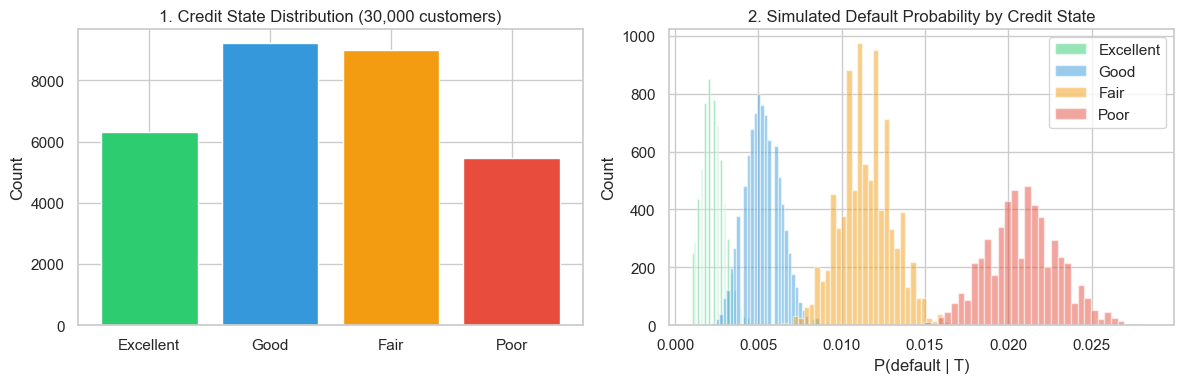

Chart 1-2 saved


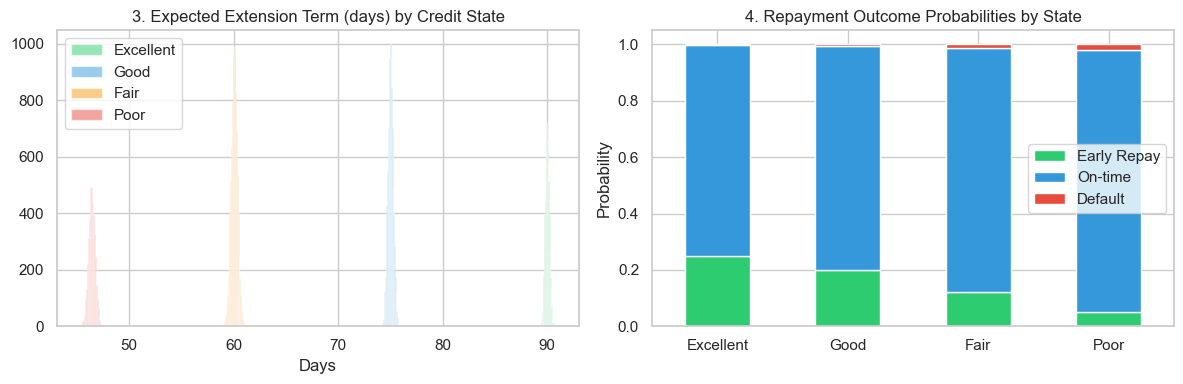

Chart 3-4 saved


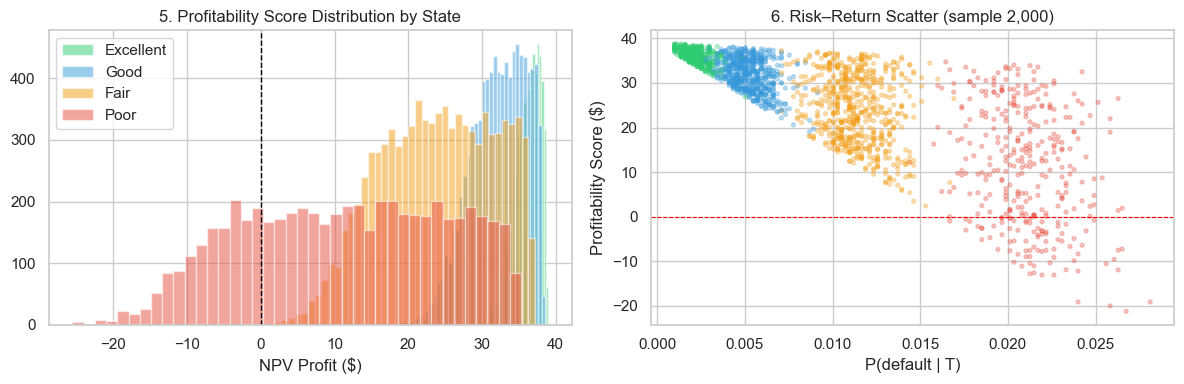

Chart 5-6 saved


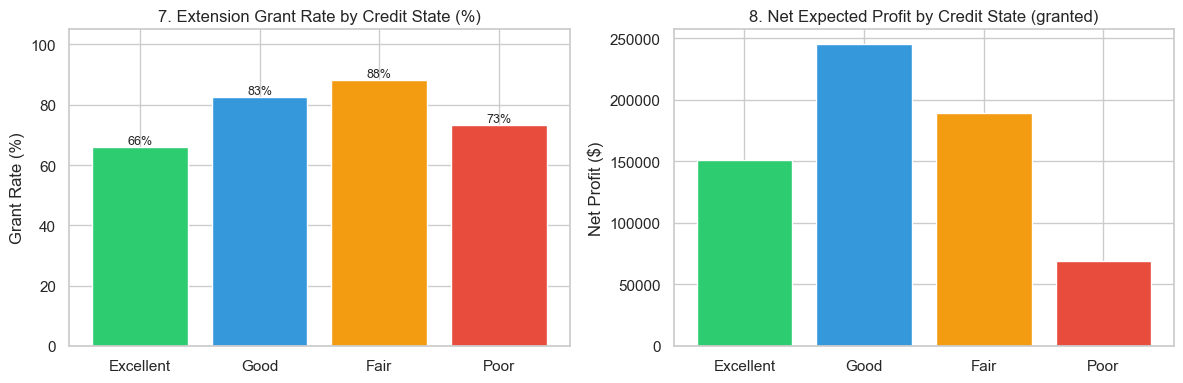

Chart 7-8 saved


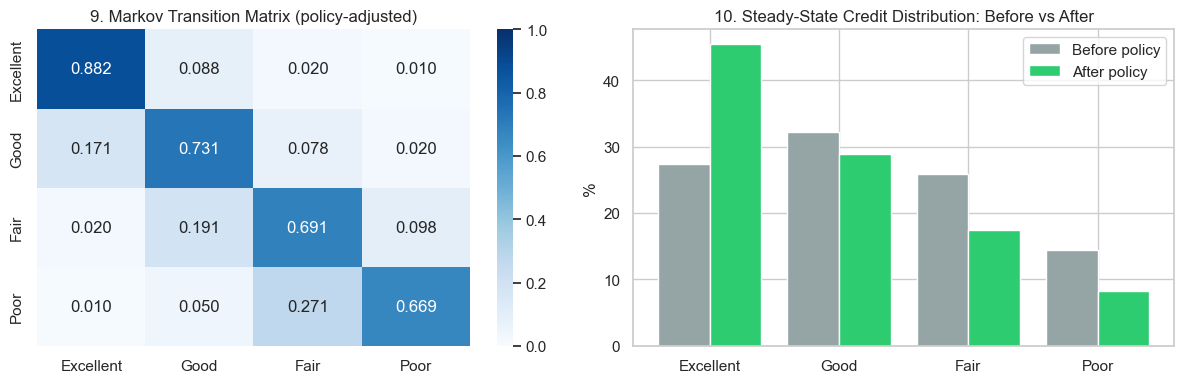

Chart 9-10 saved


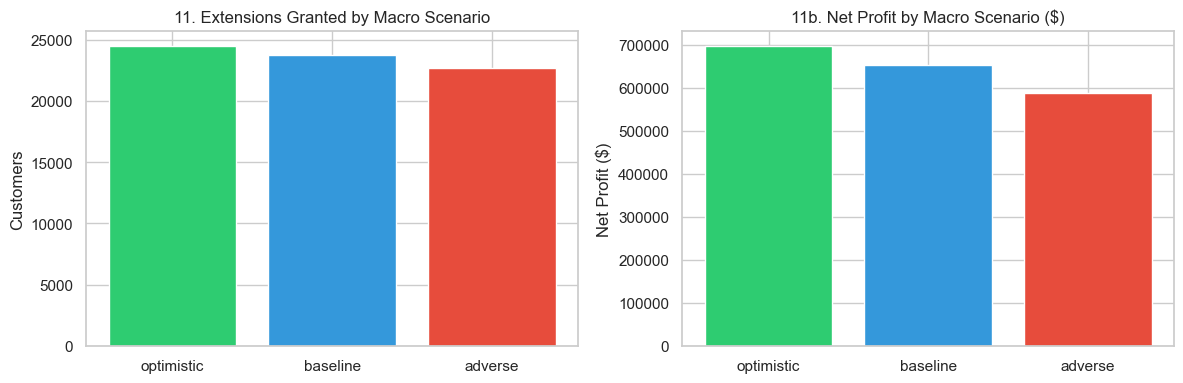

Chart 11 saved


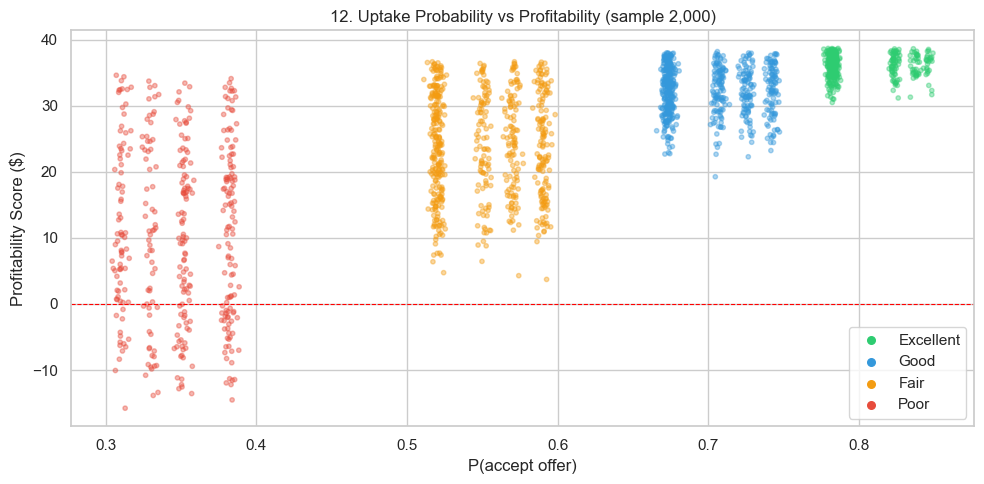

Chart 12 saved


In [15]:
def create_visualizations(df, results, sensitivity_df, tm):
    granted_mask = results['extension_granted'] > 0.5
    granted = results[granted_mask]
    denied  = results[~granted_mask]
    colors  = {'Excellent':'#2ecc71','Good':'#3498db','Fair':'#f39c12','Poor':'#e74c3c'}

    # ── 1. Credit state distribution ────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    counts = df['credit_state'].value_counts().reindex(CREDIT_STATES)
    axes[0].bar(CREDIT_STATES, counts, color=[colors[s] for s in CREDIT_STATES])
    axes[0].set_title('1. Credit State Distribution (30,000 customers)')
    axes[0].set_ylabel('Count')

    # ── 2. Default probability by state ─────────────────────────────────────────
    for state in CREDIT_STATES:
        mask = df['credit_state'] == state
        axes[1].hist(df.loc[mask,'p_default_sim'], bins=40, alpha=0.5,
                     label=state, color=colors[state])
    axes[1].set_title('2. Simulated Default Probability by Credit State')
    axes[1].set_xlabel('P(default | T)')
    axes[1].set_ylabel('Count')
    axes[1].legend()
    plt.tight_layout(); plt.savefig('te_viz_01_states_risk.png', dpi=100, bbox_inches='tight')
    plt.show(); print("Chart 1-2 saved")

    # ── 3. Variable term extension distribution ──────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for state in CREDIT_STATES:
        mask = df['credit_state'] == state
        axes[0].hist(df.loc[mask,'expected_term_days'], bins=30, alpha=0.5,
                     label=state, color=colors[state])
    axes[0].set_title('3. Expected Extension Term (days) by Credit State')
    axes[0].set_xlabel('Days'); axes[0].legend()

    # ── 4. Three-outcome breakdown ───────────────────────────────────────────────
    outcome_data = []
    for state in CREDIT_STATES:
        mask = df['credit_state'] == state
        p_early   = df.loc[mask,'p_early_sim'].mean()
        p_default = df.loc[mask,'p_default_sim'].mean()
        p_ontime  = 1 - p_early - p_default
        outcome_data.append([p_early, p_ontime, p_default])
    outcome_df = pd.DataFrame(outcome_data, index=CREDIT_STATES,
                              columns=['Early Repay','On-time','Default'])
    outcome_df.plot(kind='bar', stacked=True, ax=axes[1],
                    color=['#2ecc71','#3498db','#e74c3c'])
    axes[1].set_title('4. Repayment Outcome Probabilities by State')
    axes[1].set_ylabel('Probability'); axes[1].set_xticklabels(CREDIT_STATES, rotation=0)
    plt.tight_layout(); plt.savefig('te_viz_02_term_outcomes.png', dpi=100, bbox_inches='tight')
    plt.show(); print("Chart 3-4 saved")

    # ── 5. Profitability score distribution ──────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for state in CREDIT_STATES:
        mask = df['credit_state'] == state
        axes[0].hist(df.loc[mask,'profitability_score'], bins=40, alpha=0.5,
                     label=state, color=colors[state])
    axes[0].axvline(0, color='black', linestyle='--', lw=1)
    axes[0].set_title('5. Profitability Score Distribution by State')
    axes[0].set_xlabel('NPV Profit ($)'); axes[0].legend()

    # ── 6. Risk-return scatter ───────────────────────────────────────────────────
    sample = df.sample(2000, random_state=42)
    sc_colors = [colors[s] for s in sample['credit_state']]
    axes[1].scatter(sample['p_default_sim'], sample['profitability_score'],
                    c=sc_colors, alpha=0.3, s=8)
    axes[1].axhline(0, color='red', linestyle='--', lw=0.8)
    axes[1].set_title('6. Risk–Return Scatter (sample 2,000)')
    axes[1].set_xlabel('P(default | T)'); axes[1].set_ylabel('Profitability Score ($)')
    plt.tight_layout(); plt.savefig('te_viz_03_profitability.png', dpi=100, bbox_inches='tight')
    plt.show(); print("Chart 5-6 saved")

    # ── 7. LP decision — grant rate by state ────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    grant_rates = results.groupby('credit_state')['extension_granted'].mean().reindex(CREDIT_STATES)
    axes[0].bar(CREDIT_STATES, grant_rates * 100, color=[colors[s] for s in CREDIT_STATES])
    axes[0].set_title('7. Extension Grant Rate by Credit State (%)')
    axes[0].set_ylabel('Grant Rate (%)'); axes[0].set_ylim(0, 105)
    for i, v in enumerate(grant_rates):
        axes[0].text(i, v * 100 + 1, f"{v:.0%}", ha='center', fontsize=9)

    # ── 8. Net profit by credit state ───────────────────────────────────────────
    granted_res = results[results['extension_granted'] > 0.5]
    net_by_state = (granted_res.groupby('credit_state').apply(
        lambda g: (g['expected_revenue'] - g['expected_loss']).sum()
    )).reindex(CREDIT_STATES)
    bars = axes[1].bar(CREDIT_STATES, net_by_state, color=[colors[s] for s in CREDIT_STATES])
    axes[1].axhline(0, color='black', lw=0.8)
    axes[1].set_title('8. Net Expected Profit by Credit State (granted)')
    axes[1].set_ylabel('Net Profit ($)')
    plt.tight_layout(); plt.savefig('te_viz_04_lp_results.png', dpi=100, bbox_inches='tight')
    plt.show(); print("Chart 7-8 saved")

    # ── 9. Markov chain transition heatmap ──────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.heatmap(pd.DataFrame(tm.matrix, index=CREDIT_STATES, columns=CREDIT_STATES),
                annot=True, fmt='.3f', cmap='Blues', ax=axes[0], vmin=0, vmax=1)
    axes[0].set_title('9. Markov Transition Matrix (policy-adjusted)')

    # ── 10. Steady-state before/after policy ────────────────────────────────────
    x = np.arange(4)
    axes[1].bar(x - 0.2, transition_matrix.steady_state * 100, 0.4,
                label='Before policy', color='#95a5a6')
    axes[1].bar(x + 0.2, tm.steady_state * 100, 0.4,
                label='After policy',  color='#2ecc71')
    axes[1].set_xticks(x); axes[1].set_xticklabels(CREDIT_STATES)
    axes[1].set_title('10. Steady-State Credit Distribution: Before vs After')
    axes[1].set_ylabel('%'); axes[1].legend()
    plt.tight_layout(); plt.savefig('te_viz_05_markov.png', dpi=100, bbox_inches='tight')
    plt.show(); print("Chart 9-10 saved")

    # ── 11. Sensitivity analysis ─────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sc_names = sensitivity_df['scenario'].tolist()
    axes[0].bar(sc_names, sensitivity_df['n_granted'],
                color=['#2ecc71','#3498db','#e74c3c'])
    axes[0].set_title('11. Extensions Granted by Macro Scenario')
    axes[0].set_ylabel('Customers')

    axes[1].bar(sc_names, sensitivity_df['net_profit'],
                color=['#2ecc71','#3498db','#e74c3c'])
    axes[1].set_title('11b. Net Profit by Macro Scenario ($)')
    axes[1].set_ylabel('Net Profit ($)')
    plt.tight_layout(); plt.savefig('te_viz_06_sensitivity.png', dpi=100, bbox_inches='tight')
    plt.show(); print("Chart 11 saved")

    # ── 12. Uptake × profitability scatter ───────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 5))
    s2k = df.sample(2000, random_state=99)
    sc  = ax.scatter(s2k['uptake_probability'], s2k['profitability_score'],
                     c=[colors[s] for s in s2k['credit_state']], alpha=0.4, s=10)
    ax.axhline(0, color='red', linestyle='--', lw=0.8)
    ax.set_title('12. Uptake Probability vs Profitability (sample 2,000)')
    ax.set_xlabel('P(accept offer)'); ax.set_ylabel('Profitability Score ($)')
    for state, col in colors.items():
        ax.scatter([], [], c=col, label=state, s=30)
    ax.legend()
    plt.tight_layout(); plt.savefig('te_viz_07_uptake.png', dpi=100, bbox_inches='tight')
    plt.show(); print("Chart 12 saved")

create_visualizations(df, results_df, sensitivity_results, transition_matrix_adjusted)

## 14. Export Results

In [16]:
results_df.to_csv(RESULTS_FILE, index=False)
print(f"Results saved to {RESULTS_FILE}")
print(f"  Shape: {results_df.shape}")
print(results_df.head(3).to_string())

Results saved to term_extension_results.csv
  Shape: (30000, 13)
   customer_id  initial_loan credit_state  default_risk  p_default_sim  p_early_sim  expected_term_days  uptake_probability  profitability_score  expected_revenue  expected_loss  extension_granted  eligible
0         1001          1360         Good      0.014491       0.005029     0.190286           74.719025            0.741697            35.880649         39.232483       3.351834                1.0         1
1         1002          4272    Excellent      0.004660       0.002286     0.250286           89.726242            0.779439            34.309038         39.080490       4.771452                0.0         0
2         1003          3592         Poor      0.194742       0.022629     0.056286           46.900921            0.355762            -0.557296         39.516270      40.073566                0.0         1


## 15. Property Tests

In [17]:
def run_property_tests(df_raw, df, results, validation, sensitivity_df):
    tests = {}
    def check(name, val, msg=''):
        tests[name] = bool(val)
        print(f"  {'✓' if val else '✗'} {name:<55} {msg}")

    print("=== Property Tests ===\n")

    granted_mask = results['extension_granted'] > 0.5
    granted = results[granted_mask]

    # Data integrity
    check('P01_ExactCount',         len(df_raw) == 30_000,             f"n={len(df_raw):,}")
    check('P02_NoMissing',          df.isnull().sum().sum() == 0)
    check('P03_LoanRange',          df['initial_loan'].between(0,50000).all())
    check('P04_OnTimeRange',        df['on_time_payments_pct'].between(0,100).all())
    check('P05_FourStates',         set(df['credit_state'].unique()) == set(CREDIT_STATES))

    # Eligibility
    inelig_granted = (results.loc[results['eligible']==0,'extension_granted'] > 0.5).sum()
    check('P06_EligibilityEnforced', inelig_granted == 0, f"inelig_granted={inelig_granted}")
    check('P07_EligibilityThreshold',
          (df.loc[df['eligible']==1,'days_since_last_loan'] >= MIN_DAYS_SINCE_LOAN).all())

    # Simulation
    check('P08_SimIterations',      SIMULATION_ITERATIONS >= 3000, f"n={SIMULATION_ITERATIONS:,}")
    check('P09_DefaultProbRange',   df['p_default_sim'].between(0,1).all())
    check('P10_EarlyProbRange',     df['p_early_sim'].between(0,1).all())
    check('P11_PositiveTerm',       (df['expected_term_days'] > 0).all())
    check('P12_OutcomeSumLeq1',
          ((df['p_default_sim'] + df['p_early_sim']) <= 1.0 + 1e-6).all())
    check('P13_NonNegRevenue',      (df['expected_revenue'] >= 0).all())
    check('P14_NonNegLoss',         (df['expected_loss'] >= 0).all())

    # LP
    check('P15_BinaryDecision',
          set(np.round(results['extension_granted'].unique(), 5)).issubset({0.0, 1.0}))
    check('P16_SomethingGranted',   int(granted_mask.sum()) > 0,
          f"granted={granted_mask.sum():,}")
    check('P17_DiscountRate',       abs(NPV_DISCOUNT_RATE - 0.19) < 1e-9)
    check('P18_FlatProfit',         PROFIT_PER_EXTENSION == 40.0)
    check('P19_LGDRange',           0 < LGD <= 1)

    # Risk constraint
    if granted_mask.sum() > 0:
        total_L   = granted['initial_loan'].sum()
        risk_num  = (granted['p_default_sim'] * granted['initial_loan']).sum()
        port_risk = risk_num / max(total_L, 1.0)
        check('P20_RiskConstraint',
              port_risk <= MAX_PORTFOLIO_DEFAULT_RISK + 0.001,
              f"risk={port_risk:.4f} ≤ {MAX_PORTFOLIO_DEFAULT_RISK}")

    # Markov
    check('P21_TransitionRows',     np.allclose(transition_matrix.matrix.sum(axis=1), 1.0))
    check('P22_SteadyStateNorm',    abs(transition_matrix.steady_state.sum() - 1.0) < 1e-6)
    check('P23_NonNegTransition',   (transition_matrix.matrix >= 0).all())
    check('P24_AdjSteadyStateNorm', abs(transition_matrix_adjusted.steady_state.sum()-1.0)<1e-6)
    check('P25_PolicyReducesPoor',
          transition_matrix_adjusted.steady_state[CREDIT_STATES.index('Poor')]
          <= transition_matrix.steady_state[CREDIT_STATES.index('Poor')] + 0.05)

    # Uptake
    check('P26_UptakeRange',        df['uptake_probability'].between(0,1).all())
    check('P27_UptakeByState',
          (df.groupby('credit_state')['uptake_probability'].mean()
           .reindex(CREDIT_STATES).diff().dropna() <= 0.005).all())

    # Sensitivity
    check('P28_ThreeScenarios',     len(sensitivity_df) == 3)
    check('P29_ScenarioMonotone',
          sensitivity_df.set_index('scenario').loc['optimistic','n_granted']
          >= sensitivity_df.set_index('scenario').loc['adverse','n_granted'])

    # Profitability
    net_p = (granted['expected_revenue'] - granted['expected_loss']).sum()
    check('P30_PositiveNetProfit',  net_p > 0, f"${net_p:,.0f}")

    passed = sum(tests.values())
    total  = len(tests)
    print(f"\nResult: {passed}/{total} properties passed")
    return tests

property_results = run_property_tests(df_raw, df, results_df, validation, sensitivity_results)
passed = sum(property_results.values())
total  = len(property_results)
print(f"\nFinal score: {passed}/{total} ({100*passed/total:.0f}%)")

=== Property Tests ===

  ✓ P01_ExactCount                                          n=30,000
  ✓ P02_NoMissing                                           
  ✓ P03_LoanRange                                           
  ✓ P04_OnTimeRange                                         
  ✓ P05_FourStates                                          
  ✓ P06_EligibilityEnforced                                 inelig_granted=0
  ✓ P07_EligibilityThreshold                                
  ✓ P08_SimIterations                                       n=3,500
  ✓ P09_DefaultProbRange                                    
  ✓ P10_EarlyProbRange                                      
  ✓ P11_PositiveTerm                                        
  ✓ P12_OutcomeSumLeq1                                      
  ✓ P13_NonNegRevenue                                       
  ✓ P14_NonNegLoss                                          
  ✓ P15_BinaryDecision                                      
  ✓ P16_SomethingGranted      

## Conclusion

### What this model does differently

| Dimension | Credit-limit model | Term-extension model (this notebook) |
|---|---|---|
| **Decision** | How much to increase dollar limit | Grant/deny term extension (binary) |
| **Revenue** | $40 flat per increase event | $40 flat per extension event |
| **Risk model** | Utilisation-adjusted loss on increase amount | Hazard-rate: P(default\|T) = 1−exp(−λT/365) |
| **Duration** | Fixed cap (30% of current loan) | Variable T ~ LogNormal by state |
| **Outcomes** | Default / no-default | Early repay / on-time / default |
| **NPV** | Loss on 30% increase | Loss discounted to mid-extension term |

### Key findings
- The variable-term model reveals **duration risk**: customers in the Poor state have short offered terms (~45d) but high hazard rates (~22%/yr), meaning P(default\|T) is still meaningfully higher than for Excellent customers at 90d/1.5%/yr.
- Early repayment (25% of Excellent customers) meaningfully reduces expected loss versus a simple binary default assumption.
- The LP–Markov feedback loop shows that extending terms to reliable borrowers shifts the long-run portfolio steady-state toward better credit states — a compounding benefit not visible in a static one-period model.

### Next steps
1. Calibrate λ (hazard rate) from observed 90-DPD events in the actual book.
2. Model term length T_i as a function of individual customer data (e.g., regression on payment history).
3. Consider a Markov Decision Process (MDP) for multi-period sequential extension decisions (up to 6/year).
4. Introduce early-repayment-adjusted revenue: if a customer repays in 30d instead of 90d, the $40 may need to be pro-rated.